# Modelado de secuencias

Supongamos una secuencia generada por elementos de un conjunto $O$ de tamaño $(M)$. La secuencia tiene longitud $(N)$ y está compuesta por $(N)$ elementos $(o_1, o_2, \ldots, o_N)$.  

¿Cuales son las formas en las que podemos modelar una secuencia? Podemos hacernos las siguientes preguntas:

1. ¿Qué tipo de datos estamos modelando? ¿Son datos discretos o continuos?
2. ¿Qué tipo de secuencia estamos modelando? ¿Es una secuencia temporal, o una secuencia sin una tasa de muestreo definida?
3. ¿Qué tipo de relaciones existen entre los elementos de la secuencia? ¿Son independientes o están correlacionados?
4. ¿Qué tipo de patrones o estructuras estamos buscando en la secuencia? ¿Son patrones locales o globales?
5. ¿Qué tipo de información adicional tenemos sobre la secuencia? ¿Hay etiquetas o anotaciones disponibles?
6. ¿Qué tipo de modelo queremos construir? ¿Nos interesa poder generar nuevas secuencias, o queremos clasificar secuencias existentes?
7. ¿Nos interesa un modelado estadístico o en base a reglas de lenguaje?

Una de las principales características de una secuencia a diferencia de otro tipo de conjunto de datos, es el orden en el que aparecen los elementos. Por lo tanto, a la hora de modelar una secuencia, una estrategia común es caracterízar un elemento en base a los elementos de su vecindad. Por ejemplo, si tenemos una secuencia de palabras, podemos caracterizar una palabra en base a las palabras que la preceden y las que la siguen. Esto se conoce como contexto del elemento. 

Una diferenciación importante en tipos de modelos está dada por aquellos que son capaces de generar nuevas secuencias. En el ámbito de modelos estadísticos, esto se refiere a modelos generativos que aprenden la distribución de los datos y permiten generar nuevas muestras. En el ámbito de lenguajes formales, esto también es posible mediante gramáticas que definen reglas para generar cadenas de símbolos. Luego tenemos modelos discriminativos. En el caso estadísticos, estos modelos aprenden a partir de un conjunto de características, una frontera de descición entre secuencias de distinta clase o la probabilidad de que una secuencia sea de una clase particular. En el caso de lenguajes formales, estos modelos pueden ser gramáticas que definen reglas para clasificar cadenas de símbolos en diferentes categorías. Como ejemplo de modelo generativo podría ser un modelo de lenguaje que genera texto. Como modelo discriminativo podría ser un clasificador de texto que determina si un correo electrónico es spam o no.

Luego tenemos los paradigmas estadísticos y los basado en lenguajes formales. Una de las principales diferencias es que los estadísticos suelen estar basados en datos y manejar incertidumbre, mientras que los formales suelen estar basados en reglas.

## Modelado estadístico de secuencias discretas

### Cadenas de Markov
 
El modelo de secuencia más simple es el modelo de cadenas de Markov, un modelo estadístico que describe un proceso estocástico en el que la probabilidad de un elemento depende solo de un número fijo de elementos anteriores. Este modelo se basa en la suposición de que el futuro es independiente de toda la historia pasada.

**Cadena de Markov de primer orden**: La probabilidad de un elemento depende solo del elemento anterior. Por ejemplo, en una secuencia de palabras, la probabilidad de que aparezca una palabra depende solo de la palabra anterior.

Suposición de Markov:
$$
P(q_n = o_n | q_{n-1} = o_{n-1}, q_{n-2} = o_{n-2}, \ldots, q_1 = o_1) = P(q_n = o_n | q_{n-1} = o_{n-1})
$$

Donde \(q_n\) es el estado en el tiempo \(n\) y \(o_n\) es la observación en el tiempo \(n\). En este caso, la probabilidad de una observación depende solo de la observación anterior. Podemos simplificar la notación y escribir:

$$
P(o_n | o_{n-1}, o_{n-2}, \ldots, o_1) = P(o_n | o_{n-1})
$$

En el siguiente diagrama se muestra un ejemplo de cadena de Markov para un conjunto de estados dados por 3 palabras, "como", "estás" y "bien". La probabilidad de cada estado depende solo del estado anterior. Podemos representar la cadena como un grafo dirigido, donde los nodos representan los estados y las aristas representan las transiciones entre estados. En esta cadena podemos acceder de cualquier estado a cualquier otro estado, por lo que es un grafo totalmente conectado o cadena de Markov ergódica.

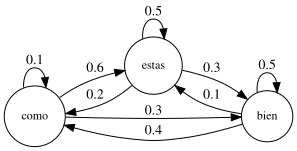

In [1]:
from graphviz import Source

dot_string = """
digraph MarkovChain {
    rankdir=LR;
    node [shape=circle, fontsize=12];

    como  -> como  [label="0.1"];
    como  -> estas  [label="0.6"];
    como  -> bien   [label="0.3"];

    estas -> como  [label="0.2"];
    estas -> estas [label="0.5"];
    estas -> bien  [label="0.3"];

    bien  -> como  [label="0.4"];
    bien  -> estas [label="0.1"];
    bien  -> bien  [label="0.5"];
}
"""

Source(dot_string)

Podemos ver las probabildiades de transición entre estados en la siguiente tabla:

<table border="1" cellpadding="5" cellspacing="0">
  <caption><strong>Matriz de transición del modelo de Markov</strong></caption>
  <thead>
    <tr>
      <th>De \ A</th>
      <th>como</th>
      <th>estas</th>
      <th>bien</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>como</th>
      <td>0.1</td>
      <td>0.6</td>
      <td>0.3</td>
    </tr>
    <tr>
      <th>estas</th>
      <td>0.2</td>
      <td>0.5</td>
      <td>0.3</td>
    </tr>
    <tr>
      <th>bien</th>
      <td>0.4</td>
      <td>0.1</td>
      <td>0.5</td>
    </tr>
  </tbody>
</table>


.

Formalmente, una cadena de Markov se especifica mediante los siguientes componentes:

- $Q = {q_1, q_2, \ldots, q_N}$:  Un conjunto de $N$ estados. En el ejemplo anterior, los símbolos son "como", "estás" y "bien".  

- $A = [a_{ij}]$:  Una matriz de probabilidad de transición $A$, donde cada elemento $a_{ij}$ representa la probabilidad de pasar del estado $i$ al estado $j$. Debe cumplirse: $ \sum_{j=1}^{N} a_{ij} = 1 \quad \forall i$

- $\pi = (\pi_1, \pi_2, \ldots, \pi_N)$:  Una distribución de probabilidad inicial sobre los estados. $\pi_i$ indica la probabilidad de que la cadena comience en el estado $i$. Algunos estados $j$ pueden tener $\pi_j = 0$, lo que significa que no pueden ser estados iniciales. Además, se cumple: $ \sum_{i=1}^{N} \pi_i = 1$

Esta cadena de Markov representa un modelo de lenguaje de bigramas. Podemos calcular la probabilidad de una secuencia de palabras utilizando la regla de la cadena de Markov. Por ejemplo, si queremos calcular la probabilidad de la secuencia "como estás bien", podemos usar la siguiente fórmula:
$$
P(q_1, q_2, q_3) = \pi_1 \cdot P(q_2 | q_1) \cdot P(q_3 | q_2)
$$
Donde $\pi_1$ es la probabilidad de empezar con la primera palabra, $P(q_2 | q_1)$ es la probabilidad de la segunda palabra dado la primera, y $P(q_3 | q_2)$ es la probabilidad de la tercera palabra dado la segunda.
En este caso, con $\pi=[1/3, 1/3, 1/3]$, la probabilidad de la secuencia "como estás bien" sería:
$$
P(como) \cdot P(estas | como) \cdot P(bien | estas) = \pi_1 a_{12} a_{23} = \frac{1}{3} \cdot 0.6 \cdot 0.3 =  0.06
$$
Esto significa que la probabilidad de que la secuencia "como estás bien" ocurra en este modelo de Markov es 0.06.

## Modelos de Markov ocultos (HMM)

Un modelo de Markov oculto (HMM) es una cadena de Markov cuya secuencia de estados no es observable, sino que está oculta detrás de una secuencia de observaciones. En un HMM, cada estado tiene una distribución de probabilidad asociada a las observaciones, lo que significa que cada estado puede generar diferentes observaciones con diferentes probabilidades.

Un HMM se especifica por los siguientes componentes:

- $Q = {q_1, q_2, \ldots, q_N}$: Un conjunto de $N$ estados.
- $A = [a_{ij}]$: Una matriz de probabilidad de transición $A$. Cada $a_{ij}$ representa la probabilidad de pasar del estado $i$ al estado $j$. La suma de las probabilidades de las transiciones que salen de un estado dado debe ser 1, formalmente $\sum_{j=1}^{N} a_{ij} = 1$ para todo $i$.
- $B = [b_i(o_t)]$: Una secuencia de verosimilitudes de observación. También se les conoce como probabilidades de emisión. Cada $b_i(o_t)$ expresa la probabilidad de que una observación $o_t$ (tomada de un vocabulario $V = {v_1, v_2, \ldots, v_V}$) sea generada desde un estado $q_i$. Esto es una matriz $B$ de tamaño $N \times V$ con elementos $b_{ik} = P(o_k|q_i)$, donde $b_{ik}$ es la probabilidad de que el estado $i$ emita la observación $k$. La suma de las probabilidades de emisión desde un estado dado debe ser 1, formalmente $\sum_{k=1}^{V} b_{ik} = 1$ para todo $i$.
- $\pi = (\pi_1, \pi_2, \ldots, \pi_N)$: Una distribución de probabilidad inicial sobre los estados. $\pi_i$ es la probabilidad de que la cadena de Markov comience en el estado $i$. Algunos estados $j$ pueden tener $\pi_j = 0$, lo que indica que no pueden ser estados iniciales. La suma de las probabilidades iniciales debe ser 1, formalmente $\sum_{i=1}^{N} \pi_i = 1$.

Además de estos componentes que definen el modelo, al HMM se le da como entrada una secuencia de observaciones. Esta secuencia es $O = {o_1, o_2, \ldots, o_T}$, una secuencia de $T$ observaciones, donde cada observación se toma del vocabulario $V$.
Un modelo oculto de Markov de primer orden incorpora dos suposiciones simplificadoras:
1. La probabilidad de un estado particular depende únicamente del estado anterior (suposición de Markov): $P(q_i|q_1...q_{i-1}) = P(q_i|q_{i-1})$.
2. La probabilidad de una observación de salida $o_i$ depende solo del estado $q_i$ que produjo la observación, y no de ningún otro estado u observación (independencia de salida): $P(o_i|q_1 \ldots q_i, \ldots, q_T, o_1, \ldots, o_i, \ldots, o_T) = P(o_i|q_i)$.
 
Las observaciones son los eventos que vemos, mientras que los estados son "ocultos" porque no los observamos directamente. El objetivo suele ser inferir la secuencia de estados ocultos a partir de la secuencia de observaciones.

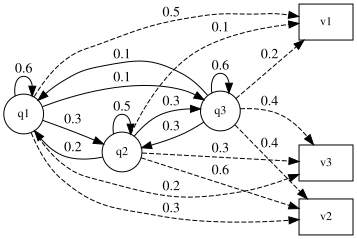

In [13]:
# graphviz HMM example diagram 3 states 3 observations

source="""
digraph HMM {
    rankdir=LR;
    node [shape=circle, fontsize=12];

    // Estados
    A [label="q1"];
    B [label="q2"];
    C [label="q3"];

    // Observaciones
    O1 [label="v1" shape=box];
    O2 [label="v2" shape=box];
    O3 [label="v3" shape=box];

    // align left to right   the observations
    { rank=same; O1; O2; O3; }

    // Arcos de emisión con estilo distinto
    A -> O1 [label="0.5", style=dashed];
    A -> O2 [label="0.3", style=dashed];
    A -> O3 [label="0.2", style=dashed];
    B -> O1 [label="0.1", style=dashed];
    B -> O2 [label="0.6", style=dashed];
    B -> O3 [label="0.3", style=dashed];
    C -> O1 [label="0.2", style=dashed];
    C -> O2 [label="0.4", style=dashed];
    C -> O3 [label="0.4", style=dashed];

    // Transiciones entre estados
    A -> A [label="0.6"];
    A -> B [label="0.3"];
    A -> C [label="0.1"];
    B -> A [label="0.2"];
    B -> B [label="0.5"];
    B -> C [label="0.3"];
    C -> A [label="0.1"];
    C -> B [label="0.3"];
    C -> C [label="0.6"];
}

"""
Source(source)

### Calculo expllicito de matrices de transición y emisión

Si conocemos la secuencia de estados y la secuencia de observaciones, podemos calcular las matrices de transición y emisión. Para ello, necesitamos contar cuántas veces ocurre cada transición y cada emisión.

Supongamos tenemos la siguiente secuencia de estados y observaciones:

```
Estados:       A B A A B    A B A B     B B A A

Observaciones: 1 2 1 3 1    1 2 3 1     1 2 1 3
```

Podemos contar las transiciones entre estados y las emisiones de observaciones desde cada estado. Por ejemplo, para la secuencia de estados, contamos cuántas veces ocurre cada transición:

$$
\begin{align*}
P(A|A) = 2/6\quad\quad & P(B|A) = 2/3 \\
P(A|B) = 4/6\quad\quad & P(B|B) = 1/3 
\end{align*}
$$

Y para la secuencia de observaciones, contamos cuántas veces ocurre cada emisión:
$$
\begin{align*}
P(1|A) = 4/7\quad\quad & P(1|B) = 3/6 \\       
P(2|A) = 0/7\quad\quad & P(2|B) = 3/6 \\
P(3|A) = 3/7\quad\quad & P(3|B) = 0/6
\end{align*}
$$

En la práctica no conocemos la secuencia de estados, pero podemos estimar las matrices de transición y emisión utilizando algoritmos.

### Algoritmos para HMMs

Dentro de los HMMs, existen tres problemas fundamentales que se pueden abordar:
1. **Problema de la verosimilitud**: Dada una secuencia de observaciones y un HMM, calcular la probabilidad de que el modelo haya generado esa secuencia. Dado un HMM $\lambda = (A,B)$ y una secuencia de observaciones $O$, determinar la verosimilitud $P(O|\lambda )$. Este problema busca calcular la probabilidad de que el modelo dado haya generado la secuencia de observaciones vista. El algoritmo Forward (Adelante) es un método eficiente para resolver este problema.
2. **Problema de decodificación**: Dada una secuencia de observaciones $O$ y un HMM $\lambda = (A,B)$, descubrir la mejor secuencia de estados ocultos $Q$. Esta tarea, también conocida como inferencia, consiste en encontrar la secuencia de estados ocultos más probable que subyace a la secuencia de observaciones dada. El algoritmo Viterbi es el algoritmo de decodificación más común para HMMs. 
3. **Problema de aprendizaje**: Dada una secuencia de observaciones $O$ y el conjunto de estados posibles en el HMM, aprender los parámetros del HMM, es decir, las matrices $A$ y $B$. El algoritmo estándar para entrenar HMMs, también conocido como aprendizaje no supervisado de los parámetros A y B, es el algoritmo forward-backward o algoritmo de Baum-Welch, el cual es un caso especial del algoritmo de Expectation-Maximization (EM). Este algoritmo permite reestimar las probabilidades de transición $A$ y las probabilidades de emisión $B$.

### Verosimilitud

Recordemos la probabilidad de una secuencia de estados ocultos $Q$:

$$
P(Q) = \prod_{t=1}^{T} P(q_t|q_{t-1}) 
$$

Si conocemos la secuencia de estados ocultos $Q$, podemos calcular la probabilidad de la secuencia de observaciones $O$ dada esa secuencia de estados.  

$$
P(O|Q) = \prod_{t=1}^{T} P(o_t|q_t)
$$

Usando la fórmula de la probabilidad conjunta $P(O,Q) = P(O|Q) \cdot P(Q)$, podemos escribir:

$$
P(O,Q) = \prod_{t=1}^{T} P(o_t|q_t) \cdot \prod_{t=1}^{T} P(q_t|q_{t-1})
$$

Esta es la probabilidad de que haya ocurrido una secuencia de estados $Q$ y una secuencia de observaciones $O$. Recordemos que la probabilidad total para una secuencia de observaciones $O$ es $P(O) = \sum_{Q} P(O,Q)$ donde sumamos sobre todas las posibles secuencias de estados $Q$. 

Para un HMM con $N$ estados y secuencias de largo $T$ tenemos que calcular $N^T$ posibles secuencias de estados. Esto puede ser computacionalmente costoso, por lo que se utiliza el algoritmo Forward (Adelante) para calcular la probabilidad de una secuencia de observaciones $O$ en un HMM. Este algoritmo utiliza programación dinámica para evitar cálculos redundantes, dado que si se tienen dos secuencias de estados que solo difieren en el estado final, no es necesario calcularlas las probabilidades anteriores por separado (ejemplo en la sección de [código](./codigo_hmm.ipynb))

El algoritmo Forward introduce los coeficientes $\alpha_t(j)=P(o_1, o_2, \ldots, o_t, q_t = j)$, que representan la probabilidad de observar la secuencia $O$ hasta el tiempo $t$ y estar en el estado $j$ en el tiempo $t$. Estos coeficientes se calculan de forma recursiva de la siguiente manera:

$$
\begin{align*}
\alpha_1(j) &= \pi_j b_j(o_1) \quad \text{para } 1 \leq j \leq N\\
\alpha_t(j) &= \sum_{i=1}^{N} \alpha_{t-1}(i)\, a_{ij}\, b_j(o_t)\quad \text{para } 1 \leq j \leq N,\ 1 < t \leq T\\
P(O) &= \sum_{i=1}^{N} \alpha_T(i)
\end{align*}
$$

De forma análoga se puede definir el algoritmo Backward (Atrás) que calcula los coeficientes $\beta_t(j)=P(o_{t+1}, o_{t+2}, \ldots, o_T | q_t = j)$, que representan la probabilidad de observar la secuencia $O$ desde el tiempo $t$ hasta el final y estar en el estado $j$ en el tiempo $t$. Estos coeficientes se calculan de forma recursiva de la siguiente manera:

$$
\begin{align*}
\beta_T(i) &= 1 \quad \text{para } 1 \leq i \leq N\\
\beta_t(i) &= \sum_{j=1}^{N} \beta_{t+1}(j)\, a_{ij}\, b_j(o_{t+1})\quad \text{para } 1 \leq i \leq N,\ 1 < t \leq T\\
P(O) &= \sum_{j=1}^{N} \pi_j b_j(o_1) \beta_1(j)
\end{align*}
$$

También es posible calcular esta probabilidad combinando $\alpha$ y $\beta$ para cualquier tiempo $t$:

$$
P(O) = \sum_{i=1}^{N} \alpha_t(i) \beta_t(i)
$$

La expresión $\alpha_t(i) \beta_t(i)$ representa la probabilidad conjunta de haber observado $O$ y de estar en el estado $i$ en el tiempo $t$.

$$
P(q_t = i , O) = \alpha_t(i) \beta_t(i)
$$

Podemos combianar estas ultimas expresiones para obtener la probabilidad de estar en el estado $i$ en el tiempo $t$ dado la secuencia de observaciones $O$:
$$
P(q_t = i | O) = \frac{P(q_t = i , O)}{P(O)} = \frac{\alpha_t(i) \beta_t(i)}{\sum_{j=1}^{N} \alpha_t(j) \beta_t(j)}
$$

### Decodificación

El problema de decodificación consiste en encontrar la secuencia de estados ocultos más probable $Q^*$ dada una secuencia de observaciones $O$. Esto se puede resolver utilizando el algoritmo Viterbi, que utiliza programación dinámica para encontrar la secuencia óptima de estados ocultos. El algoritmo Viterbi calcula los coeficientes 

$$v_t(j) = \max_{q_1, \dots, q_{t-1}} P(q_1 \dots q_{t-1}, o_1, o_2 \dots o_t, q_t = j)$$

que representan la probabilidad máxima de observar la secuencia $O$ hasta el tiempo $t$ y estar en el estado $j$ en el tiempo $t$. El principio para calcular estos coeficientes es similar al algoritmo Forward, pero en lugar de sumar las probabilidades, tomamos el máximo. Esto se debe a que estamos buscando la secuencia de estados más probable, no la probabilidad total. Al mismo tiempo es necesario incluir otra variable para recordar cuál fue el estado anterior que generó la máxima probabilidad. Esta variable se llama $\delta_t(j)$ y representa el estado anterior que generó la máxima probabilidad de estar en el estado $j$ en el tiempo $t$.


$$
\begin{align*}
v_1(j) &= \pi_j b_j(o_1) \quad \text{para } 1 \leq j \leq N \\
bt_1(j) &= 0 \quad \text{para } 1 \leq j \leq N
\end{align*}
$$


$$
\begin{align*}
v_t(j) &= \max_{i=1}^{N} \left[ v_{t-1}(i) a_{ij} b_j(o_t) \right] \quad \text{para } 1 \leq j \leq N,\ 1 < t \leq T \\
bt_t(j) &= \arg\max_{i=1}^{N} \left[ v_{t-1}(i) a_{ij} b_j(o_t) \right] \quad \text{para } 1 \leq j \leq N,\ 1 < t \leq T
\end{align*}
$$

$$
\begin{align*}
\text{Puntaje del mejor camino:} \quad & P_* =& \max_{i=1}^{N} v_T(i) \\
\text{Mejor camino:} \quad & Q^* =& \arg\max_{i=1}^{N} v_T(i)
\end{align*}
$$


### Aprendizaje

El problema de aprendizaje consiste en encontrar los parámetros del HMM, es decir las matrices A y B, Esto se puede resolver utilizando el algoritmo de Baum-Welch, que es un caso especial del algoritmo Expectation-Maximization (EM). Este algoritmo tiene una etapa (Expectation) en la que se calcula la probabilidades sobre los parámetros del modelo en base a los dataos observados y una etapa (Maximization) en la que se actualizan los parámetros del modelo en base a las probabilidades calculadas en la etapa anterior. 

Las probabilidades de la etapa de Expectación se pueden calcular utilizando los coeficientes $\alpha$ y $\beta$ si tenemos una inicialización de las matrices A y B. 
$$
P(q_t = i, q_{t+1} = j | O) = \frac{\alpha_t(i) a_{ij} b_j(o_{t+1}) \beta_{t+1}(j)}{\sum_{j=1}^{N} \alpha_t(j) \beta_t(j)}
$$

$$
P(q_t = i | O) = \frac{\alpha_t(i) \beta_t(i)}{\sum_{j=1}^{N} \alpha_t(j) \beta_t(j)}
$$

Luego se actualizan las matrices A y B utilizando estas probabilidades de transición y emisión con las siguientes fórmulas:

$$
\hat{a}_{ij} = \frac{ \sum_t P(q_t = i, q_{t+1} = j | O)}{ \sum_t P(q_t = i | O)} \\
$$

$$
\hat{b}_{ik} = \frac{ \sum_{o_t=v_k} P(q_t = i | O)}{\sum_t P(q_t = i | O)} \\
$$

Esto se hace iterativamente, en cada iteración, se calcula la probabilidad de transición y emisión utilizando las matrices A y B actuales, y luego se actualizan las matrices A y B utilizando las probabilidades calculadas en la iteración anterior. El algoritmo continúa hasta que las matrices convergen a un valor estable o hasta que se alcanza un número máximo de iteraciones.
